Imports data from TN Julia simulation

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from tqdm.auto import tqdm
import os
import sys
from math import comb
from functools import partial
from scipy.interpolate import interpn
import scipy
from skopt.acquisition import gaussian_ei, gaussian_pi, gaussian_lcb
from functools import partial

In [3]:
sys.path.append(os.path.abspath('../../src'))

In [4]:
from majo_gp import MajoQuantumKernel

### Specifcation of the Majorana system (and Majorana basis)

In [5]:
n = 30 # number of qubits

In [6]:
# Load all data:
O = np.load(f"../data/coeffs_BO_{n}q.npy")
feature_vecs = np.load(f"../data/feat_vec_BO_{n}q.npy")
indices = np.load(f"../data/indices_BO_{n}q.npy")
outputs = np.load(f"../data/outputs_BO_{n}q.npy")
ts = np.load(f"../data/t_list_BO_{n}q.npy")

In [7]:
# create results directory if it doesn't exist
results_dir = "../results"
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

In [8]:
# Skip every second value:
skip = 1
ts = ts[::skip, ::skip, :]
feature_vecs = feature_vecs[::skip, ::skip, :]
outputs = outputs[::skip, ::skip]

In [9]:
# Compute gradient (used for GD):
dt1 = np.abs(ts[0, 0, 0] - ts[1, 0, 0])  # Step size for finite difference (assumed uniform grid)
dt2 = np.abs(ts[0, 0, 1] - ts[0, 1, 1])  # Step size for finite difference (assumed uniform grid)
d1, d2 = np.gradient(outputs, dt1, dt2)
d_outputs = np.dstack((d1, d2))  # Stack gradients along the last dimension

# Compute gradient norm (Euclidean) at each grid point
grad_norm = np.linalg.norm(d_outputs, axis=-1)

# Lipschitz constant estimate = max gradient norm
min_grad = np.min(grad_norm)
print(f"Minimum gradient norm: {min_grad:.4f}")

Minimum gradient norm: 0.0038


In [10]:
# Realize multi-dimensional ts via flattening and running the kernel/GP in index mode:
ts_flattened = ts.reshape(-1, 2)  # Flatten ts for easier indexing
ts_flat_indices = np.arange(ts_flattened.shape[0])  # Create indices for flattened ts
outputs_flattened = outputs.flatten()  # Flatten outputs for easier indexing
feature_vecs_flattened = feature_vecs.reshape(-1, feature_vecs.shape[-1])  # Flatten feature vectors
d_outputs_flattened = d_outputs.reshape(-1, d_outputs.shape[-1])   # Flatten gradient map for easier indexing

In [11]:
# Infer the majorana system:
d = 2*n
# determine number of majoranas in the observable
for m in range(d):
    if comb(d, m) == feature_vecs.shape[-1]:
        break
print(f"Module B_{m}")
num_data_points = len(outputs)
n_params = ts.shape[-1] if ts.ndim > 1 else 1

Module B_1


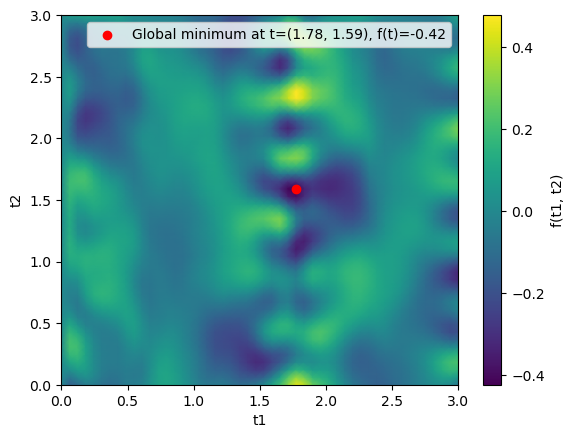

In [12]:
# Plot the data:
params = {'mathtext.default': 'regular' }          
plt.rcParams.update(params)
# Use diffe# 2D plot for 2D parameters in ts

#cont_plot = plt.contourf(ts[:,:, 0], ts[:,:, 1], outputs)
cont_plot = plt.pcolormesh(ts[:,:, 0], ts[:,:, 1], outputs, shading='gouraud')
plt.colorbar(cont_plot, label='f(t1, t2)')
# Mark global minimum:
opt_idx = np.unravel_index(np.argmin(outputs), outputs.shape)
opt_t = ts[opt_idx]
opt_val = outputs[opt_idx]
plt.scatter(opt_t[0], opt_t[1], marker='o', color='red', label=f'Global minimum at t=({opt_t[0]:.2f}, {opt_t[1]:.2f}), f(t)={opt_val:.2f}', zorder=50)
plt.xlabel('t1')
plt.ylabel('t2')
plt.legend()
plt.show()

# Bayesian optimization

In [13]:
# Determine maximizing t brute force:
print(f"Optimum at {opt_t}, {opt_val} (index {opt_idx}) at resolution {np.max(ts) - np.min(ts)}/{len(ts)}")

Optimum at [1.7755102  1.59183673], -0.4240004316633087 (index (29, 26)) at resolution 3.0/50


In [14]:
ts_1 = np.unique(ts[:, :, 0])
ts_2 = np.unique(ts[:, :, 1])
assert len(ts_1) * len(ts_2) == ts.shape[0] * ts.shape[1], "ts should be a grid of unique values in 2D"
ts_mins = np.array([ts_1.min(), ts_2.min()])
ts_maxs = np.array([ts_1.max(), ts_2.max()])

In [15]:
def fun_lookup(t, index_mode=True, interp_method=None):
    #print(t)
    t = np.asarray(t)
    if not index_mode:
        if interp_method is not None:
            t = t.clip(ts_mins, ts_maxs)  # Clip t to the bounds of ts
            return interpn((ts_1, ts_2), outputs, t, method=interp_method).item()
        else:
            #t = np.unravel_index(np.argmin(np.linalg.norm(ts - t, ord=1, axis=-1)), ts.shape[:-1])
            t = np.argmin(np.linalg.norm(ts_flattened - t, ord=1, axis=-1))

    return outputs_flattened[t]

In [ ]:
plt.rcParams["figure.figsize"] = (10, 4.8)
max_calls = 20
n_runs_bo = 100

bo_logged_ts = []
bo_logged_obs = []
bo_opt_t = []
bo_opt_obs = []
bo_opt_idx = []
bo_init = []
np.random.seed(1)

for bo_run_i in range(n_runs_bo):
    print(f"Starting Bayesian optimization run {bo_run_i + 1}/{n_runs_bo}...")

    kernel_func = MajoQuantumKernel(ts=None, majo_observable=O, majo_feature_vecs=feature_vecs_flattened, n=n, m=m)
    majo_gp = GaussianProcessRegressor(kernel=kernel_func)

    acquisition_fn = partial(gaussian_ei, xi=0.01) # Expected Improvement (xi=0.01 is default)
    #acquisition_fn = partial(gaussian_pi, xi=0.01) # Probability of Improvement (xi=0.01 is default)
    #acquisition_fn = partial(gaussian_lcb, kappa=1.96) # Lower confidence bound (kappa=1.96 is default)
    logged_ts = []
    logged_obs = []
    for i in (pbar := tqdm(range(max_calls))):

        if i == 0:  # initial guess (at zero)
            t_next = np.random.choice(ts_flat_indices)
            bo_init.append(t_next)  # Store the initial guess
            #t_next = len(ts) + 1  # Initial guess close to (0, 0) for 2D case
        else:  # Normal iteration:
            # Refit the GP (refit)
            if len(logged_ts) > 0:
                majo_gp.fit(np.asarray(logged_ts).reshape(-1, 1), logged_obs)
            # Sample the acquisition function (equi-distant) to predict the next point:
            acq_fn_vals = acquisition_fn(ts_flat_indices.reshape(-1, 1), majo_gp, y_opt=np.min(logged_obs) if len(logged_obs) > 0 else 0.0)
            t_next = np.argmax(acq_fn_vals)  # Find the index of the maximum acquisition function value

        # evaluate cost function:
        obs_next = fun_lookup(t_next)
        logged_ts.append(t_next)
        logged_obs.append(obs_next)
        print(f"Iteration {i+1}/{max_calls}, t_next={t_next}, obs_next={obs_next}")

        # Update progress bar:
        pbar.set_description(f"Iteration {i+1}/{max_calls}, t1={ts_flattened[t_next][0]:.2f}, t2={ts_flattened[t_next][0]:.2f}, f(t)={obs_next:.2f}")

    # Report optimal point found:
    opt_idx = np.argmin(logged_obs)
    logged_ts = ts_flattened[logged_ts]  # Convert logged_ts from indices back to original ts values
    opt_t, opt_obs = logged_ts[opt_idx], logged_obs[opt_idx]
    print(f"Optimal point found: t={opt_t}, f(t)={opt_obs} (after {opt_idx + 1} observations)")

    bo_logged_ts.append(logged_ts)
    bo_logged_obs.append(logged_obs)
    bo_opt_t.append(opt_t)
    bo_opt_obs.append(opt_obs)
    bo_opt_idx.append(opt_idx)

In [ ]:
# convert all lists to numpy arrays
bo_logged_ts = np.asarray(bo_logged_ts)
bo_logged_obs = np.asarray(bo_logged_obs)
bo_opt_t = np.asarray(bo_opt_t)
bo_opt_obs = np.asarray(bo_opt_obs)
bo_opt_idx = np.asarray(opt_idx)
bo_init = np.asarray(bo_init)
# Save to file (.npz)
np.savez_compressed(f"../results/opt_BO_{n}q.npz",
         bo_logged_ts=bo_logged_ts, bo_logged_obs=bo_logged_obs, bo_opt_t=bo_opt_t, bo_opt_obs=bo_opt_obs, bo_opt_idx=bo_opt_idx, bo_init=bo_init,)

In [17]:

def grad_lookup(t, index_mode=False, interp_method='linear'):
    t = np.asarray(t)
    """Lookup the gradient at a given point t."""
    if not index_mode:
        if interp_method is not None:
            t = t.clip(ts_mins, ts_maxs)  # Clip t to the bounds of ts
            return np.array([interpn((ts_1, ts_2), d_outputs[:, :, t_i], t, method=interp_method).item() for t_i in range(t.shape[-1])])
        else:
            t = np.argmin(np.linalg.norm(ts_flattened - t, ord=1, axis=-1))

    return d_outputs_flattened[t]

In [18]:
ts_fine = np.dstack((scipy.ndimage.zoom(ts[:,:, 0], zoom=3, order=1, mode='nearest'),
                     scipy.ndimage.zoom(ts[:,:, 1], zoom=3, order=1, mode='nearest')))

/var/folders/7_/vz1nj3hx5psd4x1v80v8lrch0000gn/T/ipykernel_69439/477320005.py:17: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(ts_fine[:,:, 0], ts_fine[:,:, 1], grad_test[:, :, 1], shading='nearest')
/var/folders/7_/vz1nj3hx5psd4x1v80v8lrch0000gn/T/ipykernel_69439/477320005.py:21: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(ts_fine[:,:, 0], ts_fine[:,:, 1], np.abs(d_outputs[:, :, 1].repeat(3, axis=0).repeat(3, axis=1) - grad_test[:, :, 1]), shading='nearest')


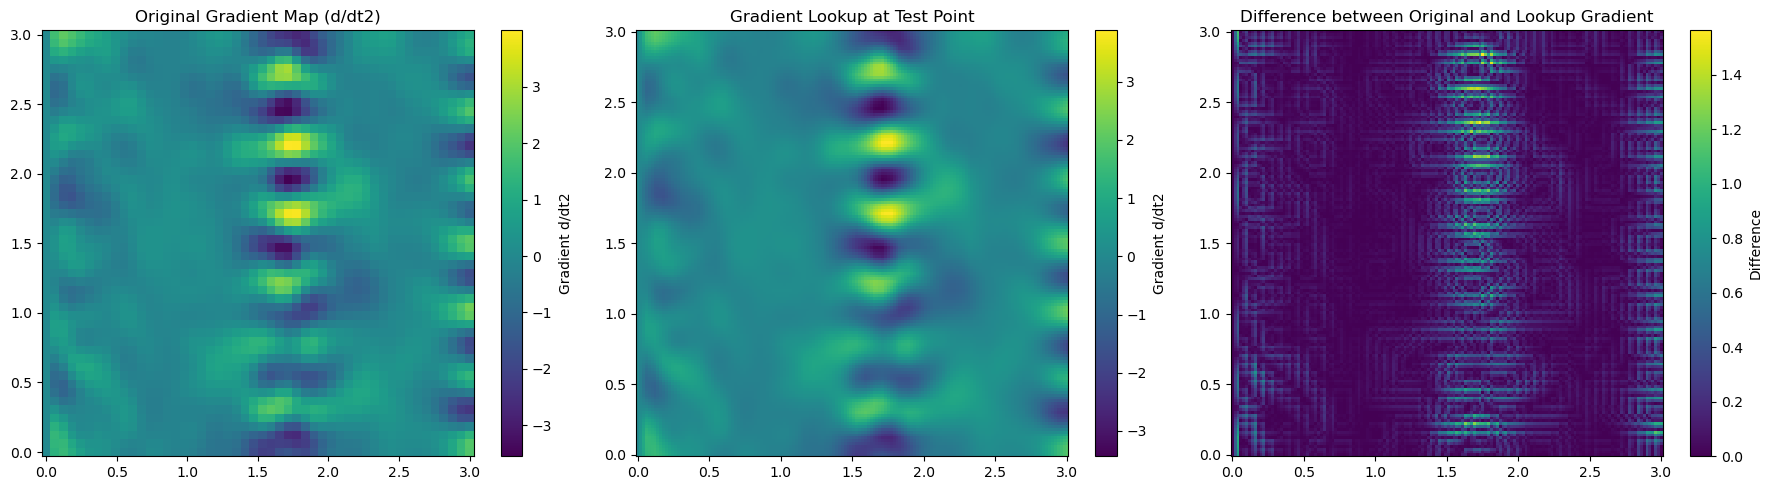

In [19]:
# Sanity check gradient lookup (and included interpolation):
# Visual inspection, plot side by side with the original gradient map
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
plt.pcolormesh(ts[:,:, 0], ts[:,:, 1], d_outputs[:, :, 1], shading='nearest')
plt.colorbar(label='Gradient d/dt2')
plt.title('Original Gradient Map (d/dt2)')
plt.subplot(1, 3, 2)
# Test gradient lookup at a point in the middle of the grid
t_test = np.array([0.5, 0.5])  # Example point
grad_test = np.full_like(ts_fine, np.nan)
for i in range(ts_fine.shape[0]):
    for j in range(ts_fine.shape[1]):
        grad_test[i, j] = grad_lookup(ts_fine[i, j], index_mode=False, interp_method='linear')
#plt.scatter(t_test[0], t_test[1], color='red', label='Test Point')
#plt.quiver(t_test[0], t_test[1], grad_test[0], grad_test[1], color='black', label='Gradient at Test Point')
plt.pcolormesh(ts_fine[:,:, 0], ts_fine[:,:, 1], grad_test[:, :, 1], shading='nearest')
plt.colorbar(label='Gradient d/dt2')
plt.title('Gradient Lookup at Test Point')
plt.subplot(1, 3, 3)  # difference between the two
plt.pcolormesh(ts_fine[:,:, 0], ts_fine[:,:, 1], np.abs(d_outputs[:, :, 1].repeat(3, axis=0).repeat(3, axis=1) - grad_test[:, :, 1]), shading='nearest')
plt.colorbar(label='Difference')
plt.title('Difference between Original and Lookup Gradient')
#plt.legend()
plt.tight_layout()
plt.show()

In [20]:
t_bounds = (ts.reshape(-1, 2).min(axis=0), ts.reshape(-1, 2).max(axis=0))

def gd_step(t, step_size=0.01, return_grad=False):
    grad = grad_lookup(t, interp_method='linear')
    t_next = t - step_size * grad

    out_bounds = (t_bounds[0] > t_next) | (t_next > t_bounds[1])
    grad[out_bounds] = 0  # Set gradient to zero if out of bounds
    t_next = np.clip(t_next, t_bounds[0], t_bounds[1])  # Ensure t_next stays within bounds


    if return_grad:
        return t_next, grad
    else:
        return t_next


In [21]:
f_lipschitz = 45.866
#f_lipschitz = max((np.linalg.norm(grad_lookup(t, interp_method=None) - grad_lookup(t_prime, interp_method=None)) / np.linalg.norm(t - t_prime))
#                   for t in ts_flattened for t_prime in ts_flattened if np.any(t > t_prime))
print(f"Estimated Lipschitz constant: {f_lipschitz:.4f}")
# Lipschitz is about 50 (45.866)

Estimated Lipschitz constant: 45.8660


In [22]:
N_GD_RUNS = 100
N_MAX_GD_STEPS = 10000  # Number of gradient descent steps per run
GD_thresh = 1e-3  # Threshold for stopping gradient descent

gd_logged_ts = np.full((N_GD_RUNS, N_MAX_GD_STEPS+1, 2), np.nan)  # Store logged ts for each GD run
gd_logged_obs = np.full((N_GD_RUNS, N_MAX_GD_STEPS+1), np.nan)
gd_opt_val =  np.full((N_GD_RUNS,), np.nan)
gd_n_f_eval = np.full((N_GD_RUNS,), -1)
gd_step_size = 1 / (f_lipschitz)  # Step size for gradient descent
print(f"Use step size {gd_step_size} for gradient descent.")


np.random.seed(1)  # For reproducibility

for n_gd_run in tqdm(range(N_GD_RUNS)):

    # Start from the optimum found by Bayesian optimization:
    t = ts_flattened[np.random.choice(ts_flat_indices)]  # Randomly choose a starting point from the flattened ts
    gd_logged_ts[n_gd_run, 0, :] = t
    gd_logged_obs[n_gd_run, 0] = fun_lookup(np.argmin(np.linalg.norm(ts_flattened - t, ord=1, axis=-1)))
    #print(f"Starting gradient descent from t={t}, f(t)={gd_logged_obs[n_gd_run, 0]}...")
    i = 0
    for i in range(N_MAX_GD_STEPS):

        t, g = gd_step(t, step_size=gd_step_size, return_grad=True)
        # force t_next to stay within the bounds
        t = np.clip(t, t_bounds[0], t_bounds[1])

        gd_logged_ts[n_gd_run, i + 1, :] = t
        gd_logged_obs[n_gd_run, i + 1] = (f_t := fun_lookup(t, index_mode=False, interp_method='linear'))  # Evaluate the function at the new point

        # No convergence criterion in place
        if (g_norm := np.linalg.norm(g)) < GD_thresh:
            #print(f"Converged by gradient norm at iter {i}")
            break
        # g_norm in progress bar:
        #pbar.set_description(f"GD Run {n_gd_run + 1}/{N_GD_RUNS}, Step {i + 1}/{N_MAX_GD_STEPS}, t={t}, f(t)={f_t:.4f}, ||g||={g_norm:.4f}")
        #if np.linalg.norm(t - gd_logged_ts[n_gd_run, i]) < GD_thresh * np.linalg.norm(gd_logged_ts[n_gd_run, i]):
        #    print(f"Converged by parameter change at iter {i}")
        #    break

        #if i % 10 == 0:
        #    print(f"Step {i+1}: t={t}, f(t)={f_t}")
    gd_n_f_eval[n_gd_run] = i + 1  # Store the number of function evaluations (steps taken)
    gd_opt_val[n_gd_run] = fun_lookup(t, index_mode=False, interp_method='linear')
    if not np.isnan(gd_logged_obs[n_gd_run,-1]):
        print(f"Maximum number of iterations reached ({N_MAX_GD_STEPS}).")

    #print(f"Final result after GD: t={t}, f(t)={f_t}, gradient={g}.")

Use step size 0.02180264248026861 for gradient descent.


  0%|          | 0/100 [00:00<?, ?it/s]

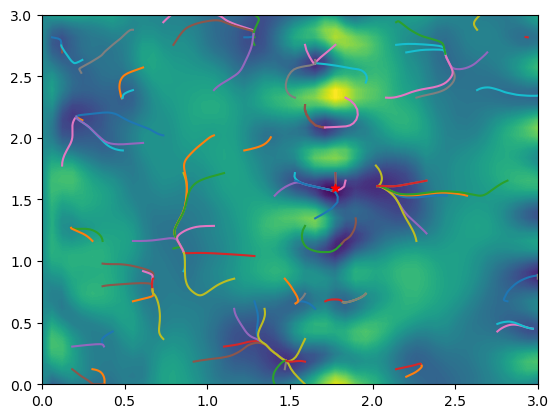

In [23]:
plt.figure()
plt.contourf(ts[:,:, 0], ts[:,:, 1], outputs, cmap='viridis', levels=100)
for xs, ys in zip(gd_logged_ts, gd_logged_obs):
    plt.plot(xs[:, 0], xs[:, 1], label='Gradient descent steps')
plt.scatter(opt_t[0], opt_t[1], marker='*', color='red', label=f'Global minimum at t=({opt_t[0]:.2f}, {opt_t[1]:.2f}), f(t)={opt_val:.2f}', zorder=50)
plt.show()

In [24]:
# Save the gradient descent results to file (.npz)
np.savez_compressed(f"../results/opt_GD_{n}q.npz",
         gd_logged_ts=gd_logged_ts, gd_logged_obs=gd_logged_obs, gd_step_size=gd_step_size,
                    gd_opt_val=gd_opt_val, gd_n_f_eval=gd_n_f_eval, gd_init=gd_logged_ts[:, 0, :])

In [25]:
# check region around optimum where GD had to be initialized to succeed:
opt_idx = np.unravel_index(np.argmin(outputs), outputs.shape)
opt_t = ts[*opt_idx]
opt_val = outputs[opt_idx]
print("Opt t", opt_idx, opt_t)

success_map = np.zeros_like(outputs, dtype=bool)  # Map to store success of GD runs
for r in (pbar := tqdm(range(0, 100))):
    any_success = False
    for x_offset in range(-r, r + 1):
        for y_offset in range(-r, r + 1):
            if x_offset not in {-r, r} and y_offset not in {-r, r}:  # must be on the border of the square
                continue
            t_init_idx = opt_idx + np.array([x_offset, y_offset])
            t_cur = ts[*t_init_idx]
            #print(t_init_idx, t_cur)

            for gd_n_it in range(N_MAX_GD_STEPS):
                t_cur, g = gd_step(t_cur, step_size=gd_step_size, return_grad=True)
                # force t_next to stay within the bounds
                t_cur = np.clip(t_cur, t_bounds[0], t_bounds[1])
                f_t = fun_lookup(t_cur, index_mode=False, interp_method='linear')

                if np.linalg.norm(g) < GD_thresh:
                    # check if converged to global optimum:
                    if np.argmin(np.linalg.norm(ts - t_cur, ord=1, axis=-1)) == np.argmin(outputs):
                        success_map[*t_init_idx] = True
                        any_success = True
                    break
                if gd_n_it == N_MAX_GD_STEPS - 1:
                    print(f"GD did not converge after {N_MAX_GD_STEPS} steps from t={t_cur}, f(t)={f_t}.")
    if not any_success:
        # set pbar to 100 to show that we are done:
        pbar.update(pbar.total - pbar.n)
        pbar.close()
        break


Opt t (29, 26) [1.7755102  1.59183673]


  0%|          | 0/100 [00:00<?, ?it/s]

In [26]:
# Statistics of GD convergence:
print(f"Success chance: {100 * np.sum(success_map) / success_map.size}%")

Success chance: 3.68%


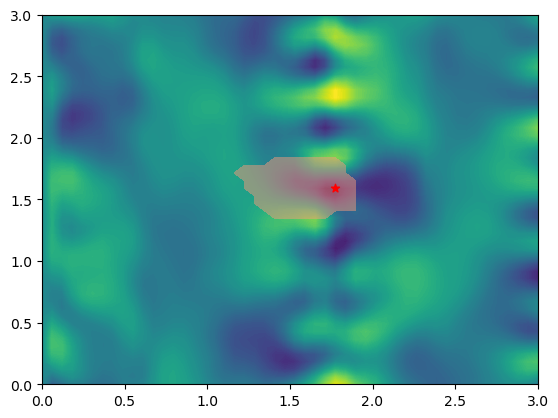

In [27]:
plt.figure()
success_map_nan = success_map.astype(float)  # Convert boolean success map to float for contourf
success_map_nan[~success_map] = np.nan  # Set failures to NaN for better visualization
plt.contourf(ts[:,:, 0], ts[:,:, 1], outputs, cmap='viridis', levels=100)
plt.contourf(ts[:,:, 0], ts[:,:, 1], success_map_nan, cmap='coolwarm_r', alpha=0.5, levels=1)
plt.scatter(opt_t[0], opt_t[1], marker='*', color='red', label=f'Global minimum at t=({opt_t[0]:.2f}, {opt_t[1]:.2f}), f(t)={opt_val:.2f}', zorder=50)
plt.show()

In [28]:
SCIPY_METHODS = ["L-BFGS-B", "COBYLA", "Nelder-Mead", "SLSQP"]
N_SCIPY_RUNS = 100
N_MAX_SCIPY_STEPS = 10000  # Number of gradient descent steps per run
scipy_logged_ts = {k: np.full((N_SCIPY_RUNS, N_MAX_SCIPY_STEPS+1, 2), np.nan) for k in SCIPY_METHODS}  # Store logged ts for each GD run
scipy_logged_obs = {k: np.full((N_SCIPY_RUNS, N_MAX_SCIPY_STEPS+1), np.nan) for k in SCIPY_METHODS}
scipy_opt = {k: np.full((N_SCIPY_RUNS, 2), np.nan) for k in SCIPY_METHODS}  # Store the optimal points found by scipy
scipy_opt_val = {k: np.full((N_SCIPY_RUNS), np.nan) for k in SCIPY_METHODS}  # Store the optimal points found by scipy
scipy_opt_n_f_eval = {k: np.full((N_SCIPY_RUNS), -1) for k in SCIPY_METHODS}  # Store the number of function evaluations by scipy
scipy_n_f_evals = {k: np.full((N_SCIPY_RUNS, N_MAX_SCIPY_STEPS+1), -1) for k in SCIPY_METHODS}  # Store the number of function evaluations by scipy
scipy_init = np.full((N_SCIPY_RUNS, 2), np.nan)  # Store the initial points for scipy optimization

np.random.seed(333)  # For reproducibility
fun = partial(fun_lookup, index_mode=False)  # Use the lookup function for scipy optimization
bounds = [(ts[:, :, 0].min(), ts[:, :, 0].max()),
          (ts[:, :, 1].min(), ts[:, :, 1].max())]  # Bounds for the optimization
it = 0
interp_method = "linear"

for scipy_method in SCIPY_METHODS:
    for scipy_run_i in tqdm(range(N_SCIPY_RUNS), desc=scipy_method):
        #print(f"Starting scipy optimization run {scipy_run_i + 1}/{N_SCIPY_RUNS}...")

        # Initial guess for scipy optimization:
        if scipy_run_i == 0:
            np.random.seed(1)  # same as BO init
        x0 = ts_flattened[np.random.choice(ts_flat_indices)]
        scipy_init[scipy_run_i] = x0

        # Run the optimization:
        scipy_logged_ts_i = []
        scipy_logged_obs_i = []
        scipy_n_f_evals_i = []
        def minimize_callback(intermediate_result):
            print(intermediate_result)
            if isinstance(intermediate_result, np.ndarray):
                x = intermediate_result
                f_val = fun(x, interp_method=interp_method)
            else:
                x = intermediate_result.x
                f_val = intermediate_result.fun
            scipy_logged_ts_i.append(x)
            scipy_logged_obs_i.append(f_val)
            scipy_n_f_evals_i.append(f_eval_counter)

        f_eval_counter = 1
        def f(x):
            global f_eval_counter
            f_eval_counter += 1
            return fun(x, interp_method=interp_method)
        def jac(x):
            global f_eval_counter
            f_eval_counter += 1
            return grad_lookup(x, interp_method=interp_method)
        scipy_logged_ts_i.append(x0)
        scipy_logged_obs_i.append(f(x0))
        scipy_n_f_evals_i.append(f_eval_counter)
        res = scipy.optimize.minimize(f, x0=x0, jac=jac, bounds=bounds,
                                      options={'maxiter': N_MAX_SCIPY_STEPS, 'maxls': 100},
                                      method=scipy_method,
                                      callback=minimize_callback
                                      )
        if not res.success:
            print(f"Scipy optimization ({scipy_method}) run {scipy_run_i + 1}/{N_SCIPY_RUNS} finished with status {res.success} after {res.nfev} iterations, message: {res.message}")
        print(res.nfev, len(scipy_logged_obs_i))
        # Store the results:
        scipy_opt[scipy_method][scipy_run_i] = np.asarray(res.x)
        scipy_opt_val[scipy_method][scipy_run_i] = res.fun
        scipy_opt_n_f_eval[scipy_method][scipy_run_i] = res.nfev
        scipy_logged_ts[scipy_method][scipy_run_i, :len(scipy_logged_ts_i), :] = np.asarray(scipy_logged_ts_i)
        scipy_logged_obs[scipy_method][scipy_run_i, :len(scipy_logged_obs_i)] = np.asarray(scipy_logged_obs_i)
        scipy_n_f_evals[scipy_method][scipy_run_i, :len(scipy_n_f_evals_i)] = np.asarray(scipy_n_f_evals_i)

L-BFGS-B:   0%|          | 0/100 [00:00<?, ?it/s]

 fun: -0.2530240206921197
   x: [ 1.394e+00  3.101e-01]
 fun: -0.2595957047763692
   x: [ 1.377e+00  2.658e-01]
 fun: -0.29022945830764146
   x: [ 1.438e+00  1.751e-01]
 fun: -0.3118730432962475
   x: [ 1.473e+00  1.824e-01]
 fun: -0.3126110789282607
   x: [ 1.473e+00  1.840e-01]
 fun: -0.3126110789282607
   x: [ 1.473e+00  1.840e-01]
26 7
 fun: -0.2628421719618751
   x: [ 2.260e-01  2.166e+00]
 fun: -0.26929302503918784
   x: [ 2.092e-01  2.174e+00]
 fun: -0.26929302503918784
   x: [ 2.092e-01  2.174e+00]
22 4
 fun: -0.23545556613082244
   x: [ 1.286e+00  2.816e+00]
20 2
 fun: -0.22053941290312876
   x: [ 1.258e+00  3.343e-01]
 fun: -0.230753618494902
   x: [ 1.304e+00  3.531e-01]
 fun: -0.24014219481025123
   x: [ 1.360e+00  3.476e-01]
 fun: -0.2701021442799039
   x: [ 1.393e+00  2.164e-01]
 fun: -0.3012179824669515
   x: [ 1.448e+00  1.829e-01]
 fun: -0.3030324277516537
   x: [ 1.460e+00  2.006e-01]
 fun: -0.30957544617261074
   x: [ 1.473e+00  1.912e-01]
 fun: -0.30957544617261074


COBYLA:   0%|          | 0/100 [00:00<?, ?it/s]

[2.28571429 0.67346939]
[1.28571429 1.67346939]
[0.39564356 0.21764693]
[0.84067892 0.44555816]
[1.50369865 0.55106506]
[1.75369849 0.5513439 ]
[1.40198996 0.32268962]
[1.31898807 0.08687044]
[1.36048902 0.20478003]
[1.46094476 0.30193915]
[1.28557037 0.36820312]
[1.46210534 0.30559015]
[1.37280509 0.33386126]
[1.40757578 0.33728206]
[1.39768919 0.29173698]
[1.39589936 0.26053828]
[1.412057   0.23378957]
[1.43171644 0.20949823]
[1.42093668 0.18016635]
[1.46286143 0.21205796]
[1.49380112 0.21645085]
[1.47833127 0.2142544 ]
[1.4617632  0.21979288]
[1.45866627 0.19700667]
[1.47096687 0.18737153]
[1.48330765 0.17778791]
[1.4647234  0.18267534]
[1.46913441 0.19496609]
[1.47432656 0.18537872]
[1.47174992 0.18916082]
[1.46988333 0.18574653]
[1.46879819 0.1841226 ]
[1.46700158 0.18335651]
[1.47022223 0.18278589]
[1.46785391 0.18387358]
[1.46913023 0.18376459]
[1.46953396 0.18348997]
[1.46967127 0.18369183]
[1.4699928  0.18405931]
[1.46970387 0.18344988]
[1.46944271 0.18377764]
[1.46946292 0.18

/var/folders/7_/vz1nj3hx5psd4x1v80v8lrch0000gn/T/ipykernel_69439/3202350363.py:57: RuntimeWarning: Method COBYLA does not use gradient information (jac).
  res = scipy.optimize.minimize(f, x0=x0, jac=jac, bounds=bounds,
/opt/anaconda3/envs/LANL_QCSS_2024/lib/python3.11/site-packages/scipy/optimize/_minimize.py:719: OptimizeWarning: Unknown solver options: maxls
  res = _minimize_cobyla(fun, x0, args, constraints, callback=callback,


...

 fun: -0.12098386278981194
   x: [ 1.382e+00  6.061e-01]
 fun: -0.12650528157105975
   x: [ 1.446e+00  6.061e-01]
 fun: -0.12650528157105975
   x: [ 1.446e+00  6.061e-01]
 fun: -0.12650528157105975
   x: [ 1.446e+00  6.061e-01]
 fun: -0.12650528157105975
   x: [ 1.446e+00  6.061e-01]
 fun: -0.12650528157105975
   x: [ 1.446e+00  6.061e-01]
 fun: -0.1275368274620511
   x: [ 1.473e+00  6.014e-01]
 fun: -0.12788812121312118
   x: [ 1.477e+00  6.214e-01]
 fun: -0.1290295494011551
   x: [ 1.531e+00  6.219e-01]
 fun: -0.13231768312921433
   x: [ 1.535e+00  6.419e-01]
 fun: -0.13231768312921433
   x: [ 1.535e+00  6.419e-01]
 fun: -0.13231768312921433
   x: [ 1.535e+00  6.419e-01]
 fun: -0.13378199460060097
   x: [ 1.519e+00  6.629e-01]
 fun: -0.13914286318181213
   x: [ 1.535e+00  6.756e-01]
 fun: -0.13914286318181213
   x: [ 1.535e+00  6.756e-01]
 fun: -0.13914286318181213
   x: [ 1.535e+00  6.756e-01]
 fun: -0.13914286318181213
   x: [ 1.535e+00  6.756e-01]
 fun: -0.13914286318181213
   x: 

/var/folders/7_/vz1nj3hx5psd4x1v80v8lrch0000gn/T/ipykernel_69439/3202350363.py:57: RuntimeWarning: Method Nelder-Mead does not use gradient information (jac).
  res = scipy.optimize.minimize(f, x0=x0, jac=jac, bounds=bounds,
/var/folders/7_/vz1nj3hx5psd4x1v80v8lrch0000gn/T/ipykernel_69439/3202350363.py:57: OptimizeWarning: Unknown solver options: maxls
  res = scipy.optimize.minimize(f, x0=x0, jac=jac, bounds=bounds,


 fun: -0.0885025593503279
   x: [ 8.357e-01  1.102e+00]
 fun: -0.0885025593503279
   x: [ 8.357e-01  1.102e+00]
 fun: -0.0885025593503279
   x: [ 8.357e-01  1.102e+00]
 fun: -0.08942862472185392
   x: [ 8.656e-01  1.088e+00]
 fun: -0.08981381587312223
   x: [ 8.631e-01  1.071e+00]
 fun: -0.08981381587312223
   x: [ 8.631e-01  1.071e+00]
 fun: -0.09002428002637503
   x: [ 8.611e-01  1.085e+00]
 fun: -0.09039874801646366
   x: [ 8.560e-01  1.084e+00]
 fun: -0.09039874801646366
   x: [ 8.560e-01  1.084e+00]
 fun: -0.09040514332512958
   x: [ 8.580e-01  1.088e+00]
 fun: -0.09040514332512958
   x: [ 8.580e-01  1.088e+00]
 fun: -0.09044539107782731
   x: [ 8.578e-01  1.083e+00]
 fun: -0.09050726236370676
   x: [ 8.570e-01  1.085e+00]
 fun: -0.09050726236370676
   x: [ 8.570e-01  1.085e+00]
 fun: -0.09050726236370676
   x: [ 8.570e-01  1.085e+00]
 fun: -0.09050726236370676
   x: [ 8.570e-01  1.085e+00]
 fun: -0.09052882298928865
   x: [ 8.571e-01  1.083e+00]
 fun: -0.09052882298928865
   x: [

SLSQP:   0%|          | 0/100 [00:00<?, ?it/s]

[1.48703787 0.        ]
[1.09780204e+00 1.66533454e-16]
[1.40378454 0.2309799 ]
[1.61984335e+00 2.77555756e-17]
[1.50735696 0.16814033]
[1.46865117 0.2097967 ]
[1.46486412 0.19109121]
[1.47803678 0.18888531]
[1.47914995 0.19113633]
24 10
[2.77555756e-17 2.44199684e+00]
[0.17525411 2.123979  ]
[0.28211244 2.18923489]
16 4
[1.18349612 2.89474943]
12 2
[2.01781987 0.47186318]
[1.35120889 0.10445009]
[1.5152519 0.       ]
[1.50035442 0.1280824 ]
[1.47338652 0.18406687]
[1.48269897 0.19263644]
21 7
[1.24314339 0.        ]
[1.49458751 0.27071737]
[1.53365954 0.13393132]
[0.80281675 0.17932247]
[1.48052332 0.19665607]
[1.4756319  0.19023418]
[1.47781021 0.19123023]
21 8
[0.1532037 3.       ]
[5.55111512e-17 2.85702945e+00]
[0.11682063 2.77047701]
16 4
[0.17436013 2.92908064]
[0.00900972 2.28118345]
[0.47487404 2.55770549]
[0.19300588 2.61939711]
[0.         2.74362817]
[0.        2.7572289]
[2.22044605e-16 2.76619326e+00]
[0.         2.77233931]
[0.         2.78927172]
[0.10332547 3.        ]

In [29]:
scipy.optimize.show_options("minimize", "L-BFGS-B")  # Show the options for L-BFGS-B

Minimize a scalar function of one or more variables using the L-BFGS-B
algorithm.

Options
-------
disp : None or int
    If `disp is None` (the default), then the supplied version of `iprint`
    is used. If `disp is not None`, then it overrides the supplied version
    of `iprint` with the behaviour you outlined.
maxcor : int
    The maximum number of variable metric corrections used to
    define the limited memory matrix. (The limited memory BFGS
    method does not store the full hessian but uses this many terms
    in an approximation to it.)
ftol : float
    The iteration stops when ``(f^k -
    f^{k+1})/max{|f^k|,|f^{k+1}|,1} <= ftol``.
gtol : float
    The iteration will stop when ``max{|proj g_i | i = 1, ..., n}
    <= gtol`` where ``proj g_i`` is the i-th component of the
    projected gradient.
eps : float or ndarray
    If `jac is None` the absolute step size used for numerical
    approximation of the jacobian via forward differences.
maxfun : int
    Maximum number of fu

In [30]:
np.savez_compressed(f"../results/opt_scipy_{n}q.npz",
                    **({ f"{scipy_method}_logged_ts": scipy_logged_ts[scipy_method] for scipy_method in SCIPY_METHODS} |
                       { f"{scipy_method}_logged_obs": scipy_logged_obs[scipy_method] for scipy_method in SCIPY_METHODS} |
                       { f"{scipy_method}_opt": scipy_opt[scipy_method] for scipy_method in SCIPY_METHODS} |
                       { f"{scipy_method}_opt_val": scipy_opt_val[scipy_method] for scipy_method in SCIPY_METHODS} |
                       { f"{scipy_method}_opt_n_f_eval": scipy_opt_n_f_eval[scipy_method] for scipy_method in SCIPY_METHODS} |
                       { f"{scipy_method}_n_f_evals": scipy_n_f_evals[scipy_method] for scipy_method in SCIPY_METHODS} |
                       { f"{scipy_method}_init": scipy_init for scipy_method in SCIPY_METHODS }
                       ))

In [32]:
# Random samples:
max_n_evals = 1000
n_samples_per_eval = 10000  # Number of random samples per evaluation point
rand_n_evals = np.arange(1, max_n_evals + 1)
rand_opt_diffs = [[] for _ in range(max_n_evals)]
for i in tqdm(range(1, max_n_evals + 1)):
    # Generate random samples for each evaluation point
    for _ in range(n_samples_per_eval):
        # Randomly sample a point from the ts_flattened
        rand_idx = np.random.randint(0, len(ts_flat_indices), i + 1)
        rand_t = ts_flattened[rand_idx]
        rand_min_obs = np.min(outputs_flattened[rand_idx])
        # Calculate the difference from the optimal value
        rand_opt_diff = np.abs(rand_min_obs - opt_val)
        rand_opt_diffs[i - 1].append(rand_opt_diff)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [33]:
np.savez_compressed(f"../results/opt_rand_{n}q.npz",
                    rand_n_evals=rand_n_evals,
                    rand_opt_diffs=rand_opt_diffs,
                    n_samples_per_eval=n_samples_per_eval)